In [1]:
from bending import *
from plot import *


# Cantilever beam - Mesh problems

In this notebook we are going to use FEM to calculate the displacement on a cantilever beam under distributed load, with some mesh inconsistences. 


In [2]:
# Input
E = 210e3 # 210GPa = 210e9 N/m^2 = 210e3 N/mm^2
nu = 0.3  
F = [0, -10]

# Solution 



First, lets solve the beam using a simple mesh, with only one surface to mesh, just as show below.

In [3]:
# Mesh

geo_file = """
lc = DefineNumber[ 30, Name "Parameters/lc" ];
Point(1) = {0, 0, 0, lc};
Point(2) = {500, 0, 0, lc};
Point(3) = {500, 100, 0, lc};
Point(4) = {0, 100, 0, lc};
Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line Loop(5) = {3, 4, 1, 2};
Plane Surface(5) = {5};
Physical Surface(8) = {5};
Physical Line("XBlocked") = {4};
Physical Line("YBlocked") = {4};
Physical Line("Traction") = {3};
"""

open("beam.geo", 'w').write(geo_file)

points, conn = meshGeo('beam.geo', order=1)


Info    : Running '/home/dantas/.local/bin/gmsh -2 -order 1 -o tmp.msh beam.geo' [Gmsh 4.9.5, 1 node, max. 1 thread]
Info    : Started on Wed May  4 08:22:10 2022
Info    : Reading 'beam.geo'...
Info    : Done reading 'beam.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000245468s, CPU 0.000537s)
Info    : Meshing 2D...
Info    : Meshing surface 5 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00190144s, CPU 0.003462s)
Info    : 96 nodes 194 elements
Info    : Writing 'tmp.msh'...
Info    : Done writing 'tmp.msh'
Info    : Stopped on Wed May  4 08:22:10 2022 (From start: Wall 0.0117908s, CPU 0.347989s)
Mesh generated



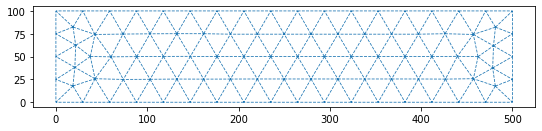

In [4]:
plotMesh(points, conn)

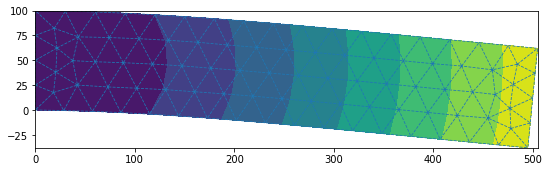

In [5]:
model,mesh = solve(F, 'tmp.msh')
u = model.getDisplacement()
n_nodes = points.shape[0]
plotMesh(points+u.reshape(n_nodes, 2)*10, conn, u)

# Example 01

Divide the beam in two parts.

In [6]:
# Mesh

geo_file = """
lc = DefineNumber[ 30, Name "Parameters/lc" ];

Point(1) = {0, 0, 0, lc};
Point(2) = {500, 0, 0, lc};
Point(3) = {500, 50, 0, lc};
Point(4) = {0, 50, 0, lc};

Point(5) = {0, 50, 0, lc};
Point(6) = {500, 50, 0, lc};
Point(7) = {500, 100, 0, lc};
Point(8) = {0, 100, 0, lc};

Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line(5) = {5, 6};
Line(6) = {6, 7};
Line(7) = {7, 8};
Line(8) = {8, 5};

Line Loop(9) = {3, 4, 1, 2};
Line Loop(10) = {7, 8, 5, 6};

Surface(11) = {9};
Surface(12) = {10};

Physical Surface(1) = {11,12};
Physical Line("XBlocked") = {4,8};
Physical Line("YBlocked") = {4,8};
Physical Line("Traction") = {7};

"""

open("beam.geo", 'w').write(geo_file)

points, conn = meshGeo('beam.geo', order=1)


Info    : Running '/home/dantas/.local/bin/gmsh -2 -order 1 -o tmp.msh beam.geo' [Gmsh 4.9.5, 1 node, max. 1 thread]
Info    : Started on Wed May  4 08:22:11 2022
Info    : Reading 'beam.geo'...
Info    : Done reading 'beam.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 50%] Meshing curve 5 (Line)
Info    : [ 70%] Meshing curve 6 (Line)
Info    : [ 80%] Meshing curve 7 (Line)
Info    : [ 90%] Meshing curve 8 (Line)
Info    : Done meshing 1D (Wall 0.00380679s, CPU 0.014618s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 11 (Surface, Frontal-Delaunay)
Info    : [ 50%] Meshing surface 12 (Surface, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00521192s, CPU 0.002602s)
Info    : 113 nodes 230 elements
Info    : Writing 'tmp.msh'...
Info    : Done writing 'tmp.msh'
Info    : Stopped on Wed May  4 08:22:11 2022 (From start:

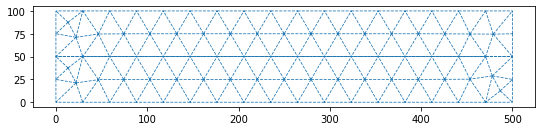

In [7]:
plotMesh(points, conn)

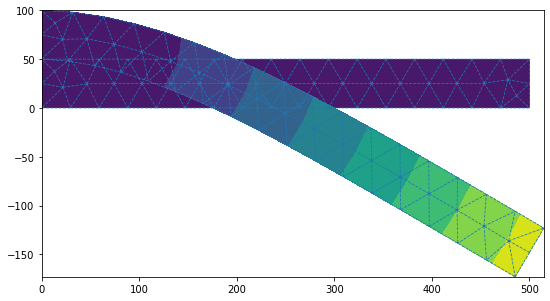

In [8]:
model,mesh = solve(F, 'tmp.msh')
u = model.getDisplacement()
n_nodes = points.shape[0]
plotMesh(points+u.reshape(n_nodes, 2)*10, conn, u)

### What is wrong in the previous mesh definition?

There is a duplicate line!


### Correct mesh for example 1

Info    : Running '/home/dantas/.local/bin/gmsh -2 -order 1 -o tmp.msh beam.geo' [Gmsh 4.9.5, 1 node, max. 1 thread]
Info    : Started on Wed May  4 08:22:11 2022
Info    : Reading 'beam.geo'...
Info    : Done reading 'beam.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.00346089s, CPU 0.00716s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 10 (Surface, Frontal-Delaunay)
Info    : [ 50%] Meshing surface 11 (Surface, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00535746s, CPU 0.004302s)
Info    : 94 nodes 209 elements
Info    : Writing 'tmp.msh'...
Info    : Done writing 'tmp.msh'
Info    : Stopped on Wed May  4 08:22:11 2022 (From start: Wall 0.0267535s, CPU 0.321843s)
Mesh gene

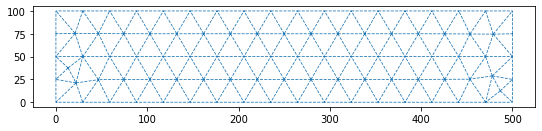

In [9]:
# Correct mesh for example 01
# Mesh

geo_file = """
lc = DefineNumber[ 30, Name "Parameters/lc" ];
Point(1) = {0, 0, 0, lc};
Point(2) = {500, 0, 0, lc};
Point(3) = {500, 50, 0, lc};
Point(4) = {0, 50, 0, lc};

Point(5) = {500, 100, 0, lc};
Point(6) = {0, 100, 0, lc};


Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line(5) = {3, 5};
Line(6) = {5, 6};
Line(7) = {6, 4};

Line Loop(8) = {3, 4, 1, 2};
Line Loop(9) = {6, 7, -3, 5};

Surface(10) = {8};
Surface(11) = {9};

Physical Surface(8) = {10,11};
Physical Line("XBlocked") = {4,7};
Physical Line("YBlocked") = {4,7};
Physical Line("Traction") = {6};

"""

open("beam.geo", 'w').write(geo_file)

points, conn = meshGeo('beam.geo', order=1)
plotMesh(points, conn)

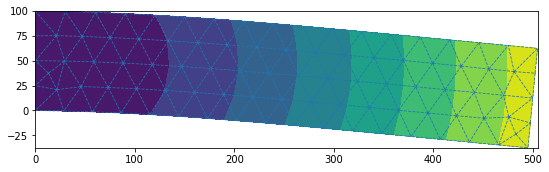

In [10]:
model,mesh = solve(F, 'tmp.msh')
u = model.getDisplacement()
n_nodes = points.shape[0]
plotMesh(points+u.reshape(n_nodes, 2)*10, conn, u)

## Example 02

Now, lets separate the beam in 4 parts

In [11]:
# Mesh

geo_file = """
lc = DefineNumber[ 30, Name "Parameters/lc" ];

Point(1) = {0, 0, 0, lc};
Point(2) = {250, 0, 0, lc};
Point(3) = {250, 50, 0, lc};
Point(4) = {0, 50, 0, lc};
Point(5) = {250, 100, 0, lc};
Point(6) = {0, 100, 0, lc};
Point(7) = {500, 0, 0, lc};
Point(8) = {500, 50, 0, lc};
Point(9) = {500, 100, 0, lc};
Point(10) = {250, 100, 0, lc};
Point(11) = {250, 50, 0, lc};

Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line(5) = {3, 5};
Line(6) = {5, 6};
Line(7) = {6, 4};
Line(8) = {2, 7};
Line(9) = {7, 8};
Line(10) = {8, 3};
Line(11) = {8, 9};
Line(12) = {9, 10};
Line(13) = {10, 11};
Line(14) = {11, 8};


Line Loop(12) = {3, 4, 1, 2};
Line Loop(13) = {6, 7, -3, 5};
Line Loop(14) = {10, -2, 8, 9};
Line Loop(15) = {12, 13, 14, 11};

Surface(16) = {12};
Surface(17) = {13};
Surface(18) = {14};
Surface(19) = {15};

Physical Surface(8) = {16,17,18,19};
Physical Line("XBlocked") = {4,7};
Physical Line("YBlocked") = {4,7};
Physical Line("Traction") = {9};

"""

open("beam.geo", 'w').write(geo_file)

points, conn = meshGeo('beam.geo', order=1)


Info    : Running '/home/dantas/.local/bin/gmsh -2 -order 1 -o tmp.msh beam.geo' [Gmsh 4.9.5, 1 node, max. 1 thread]
Info    : Started on Wed May  4 08:22:12 2022
Info    : Reading 'beam.geo'...
Info    : Done reading 'beam.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 6 (Line)
Info    : [ 50%] Meshing curve 7 (Line)
Info    : [ 50%] Meshing curve 8 (Line)
Info    : [ 60%] Meshing curve 9 (Line)
Info    : [ 70%] Meshing curve 10 (Line)
Info    : [ 80%] Meshing curve 11 (Line)
Info    : [ 80%] Meshing curve 12 (Line)
Info    : [ 90%] Meshing curve 13 (Line)
Info    : [100%] Meshing curve 14 (Line)
Info    : Done meshing 1D (Wall 0.000800614s, CPU 0s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 16 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 17 (Sur

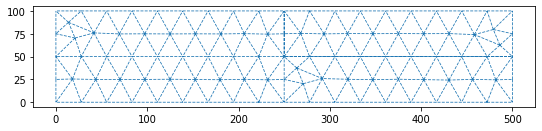

In [12]:
plotMesh(points, conn)

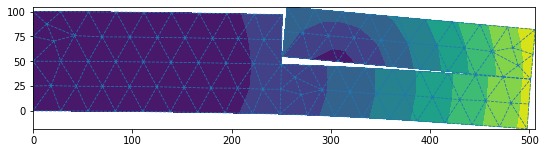

In [13]:
model,mesh = solve(F, 'tmp.msh')
u = model.getDisplacement()
n_nodes = points.shape[0]
plotMesh(points+u.reshape(n_nodes, 2)*10, conn, u)

Again there are duplicate lines!


### Correct mesh for example 2

Info    : Running '/home/dantas/.local/bin/gmsh -2 -order 1 -o tmp.msh beam.geo' [Gmsh 4.9.5, 1 node, max. 1 thread]
Info    : Started on Wed May  4 08:22:12 2022
Info    : Reading 'beam.geo'...
Info    : Done reading 'beam.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 50%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.00205498s, CPU 0.004765s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 16 (Surface, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 17 (Surface, Frontal-Delaunay)
Info    : [ 50%] Meshing surface 18 (Surface, Fronta

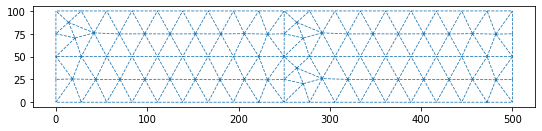

In [14]:
# Correct mesh for example 02
# Mesh

geo_file = """
lc = DefineNumber[ 30, Name "Parameters/lc" ];

Point(1) = {0, 0, 0, lc};
Point(2) = {250, 0, 0, lc};
Point(3) = {250, 50, 0, lc};
Point(4) = {0, 50, 0, lc};
Point(5) = {250, 100, 0, lc};
Point(6) = {0, 100, 0, lc};
Point(7) = {500, 0, 0, lc};
Point(8) = {500, 50, 0, lc};
Point(9) = {500, 100, 0, lc};

Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line(5) = {3, 5};
Line(6) = {5, 6};
Line(7) = {6, 4};
Line(8) = {2, 7};
Line(9) = {7, 8};
Line(10) = {8, 3};
Line(11) = {8, 9};
Line(12) = {9, 5};


Line Loop(12) = {3, 4, 1, 2};
Line Loop(13) = {6, 7, -3, 5};
Line Loop(14) = {10, -2, 8, 9};
Line Loop(15) = {12, -5, -10, 11};

Surface(16) = {12};
Surface(17) = {13};
Surface(18) = {14};
Surface(19) = {15};

Physical Surface(8) = {16,17,18,19};
Physical Line("XBlocked") = {4,7};
Physical Line("YBlocked") = {4,7};
Physical Line("Traction") = {9};

"""

open("beam.geo", 'w').write(geo_file)

points, conn = meshGeo('beam.geo', order=1)
plotMesh(points, conn)

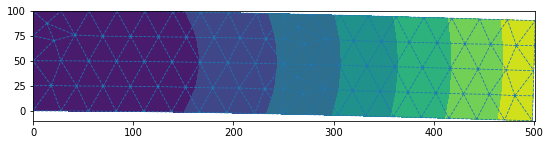

In [15]:
model,mesh = solve(F, 'tmp.msh')
u = model.getDisplacement()
n_nodes = points.shape[0]
plotMesh(points+u.reshape(n_nodes, 2)*10, conn, u)

## Example 03

In this example we are going to use a mesh already given in the file 'beamex3.msh'


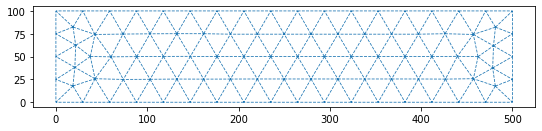

In [16]:
# Mesh

points, conn = readMesh('beamex3.msh')
plotMesh(points, conn)

In [17]:
model,mesh = solve(F, 'beamex3.msh')
u = model.getDisplacement()
n_nodes = points.shape[0]
plotMesh(points+u.reshape(n_nodes, 2)*10, conn, u)

Exception: akantu::debug::IntegratorGaussException : Negative jacobian computed, possible problem in the element node ordering (Quadrature Point 0:146:_triangle_3:not_ghost) [../../src/fe_engine/integrator_gauss_inline_impl.hh:200]

See the error message: \
     Negative jacobian computed!

### What is wrong in the mesh definition that could have lead to a negative jacobian?

There is an inverted element. Usually, the computation of geometric quantities, like the Jacobian determinant, assume an orientation of the connectivity of the elements. So, if you programmed assuming triangles have their nodes ordered counter-clockwise and some element has nodes listed clockwise, you just defined an inverted element, and the Jacobian determinant is going to be negative. \
Likewise if the Jacobian determinant is equal to zero, you have a collapsed element (a rectangle down to a line, or a line down to a point, etc). \
Things get even more complicated if you are using 3D elements.